This project sourced in large part from the University of Waterloo's CS480/680 Introduction to Machine Learning

# Import libraries 
Do not use any other Python library.

numpy - Linear algebra library for handling vectors and matrices, collectively processed as numpy arrays.

matplotlib - Graphing library for visualizing data and results.

sklearn - Machine learning library from which we will source some of our datasets. 

time - Simple library for timing code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.datasets import fetch_california_housing
from time import time

# Uncomment below to allow matplotlib to display interactive plots in the notebook
%matplotlib widget

# Load Datasets

These functions load data for regression into RAM for python to use. Some load from files on the device, while some download data from the internet.

Inputs:

*   **plot**: boolean for whether to plot the data points

Outputs:

*   **train_inputs**: numpy array of N training data points x M features
*   **train_targets**: numpy array of N training targets
*   **test_inputs**: numpy array of N' test data points x M features
*   **test_targets**: numpy array of N' test targets

In [2]:
def load_synthetic_excel_data(plot=True):
    # Load synthetic data from CSV files
    test_inputs = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension/test_inputs.csv', delimiter=',')
    test_inputs = test_inputs.reshape(-1, 1)  # Ensure it's a 2D array
    test_targets = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension/test_targets.csv', delimiter=',')
    train_inputs = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension/train_inputs.csv', delimiter=',')
    train_inputs = train_inputs.reshape(-1, 1)  # Ensure it's a 2D array
    train_targets = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension/train_targets.csv', delimiter=',')

    train_sample_count = 20
    test_sample_count = 100
    np.random.seed(42)
    train_samples = np.random.choice(train_inputs.shape[0], train_sample_count, replace=False)
    test_samples = np.random.choice(test_inputs.shape[0], test_sample_count, replace=False)
    train_inputs = train_inputs[train_samples]
    train_targets = train_targets[train_samples]
    test_inputs = test_inputs[test_samples]
    test_targets = test_targets[test_samples]

    if plot:
        plt.figure(figsize=(10, 5))
        plt.scatter(train_inputs, train_targets, color='blue', label='Train Data')
        plt.scatter(test_inputs, test_targets, color='red', label='Test Data')
        plt.xlabel('Input Feature')
        plt.ylabel('Target Value')
        plt.title('Synthetic One-Dimensional Data')
        plt.legend()
        plt.grid()
        plt.show()

    return train_inputs, train_targets, test_inputs, test_targets

def load_synthetic_quadratic_excel_data(plot=True): 
    # Load synthetic data from CSV files
    test_inputs = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension-quad/test_inputs.csv', delimiter=',')
    test_inputs = test_inputs.reshape(-1, 1)  # Ensure it's a 2D array
    test_targets = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension-quad/test_targets.csv', delimiter=',')
    train_inputs = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension-quad/train_inputs.csv', delimiter=',')
    train_inputs = train_inputs.reshape(-1, 1)  # Ensure it's a 2D array
    train_targets = np.genfromtxt('../data/regression-datasets/synthetic-one-dimension-quad/train_targets.csv', delimiter=',')

    train_sample_count = 20
    test_sample_count = 100
    np.random.seed(42)
    train_samples = np.random.choice(train_inputs.shape[0], train_sample_count, replace=False)
    test_samples = np.random.choice(test_inputs.shape[0], test_sample_count, replace=False)
    train_inputs = train_inputs[train_samples]
    train_targets = train_targets[train_samples]
    test_inputs = test_inputs[test_samples]
    test_targets = test_targets[test_samples]

    if plot:
        plt.figure(figsize=(10, 5))
        plt.scatter(train_inputs, train_targets, color='blue', label='Train Data')
        plt.scatter(test_inputs, test_targets, color='red', label='Test Data')
        plt.xlabel('Input Feature')
        plt.ylabel('Target Value')
        plt.title('Synthetic One-Dimensional Data')
        plt.legend()
        plt.grid()
        plt.show()

    return train_inputs, train_targets, test_inputs, test_targets

def load_sklearn_california_housing(plot=True): 
    # Load the California housing dataset from scikit-learn
    california_housing = fetch_california_housing()
    train_inputs = california_housing.data[2000:]
    train_targets = california_housing.target[2000:]
    test_inputs = california_housing.data[0:2000]
    test_targets = california_housing.target[0:2000]

    # Center and normalize the data
    mean = np.mean(train_inputs, axis=0)
    stdev = np.std(train_inputs, axis=0)
    train_inputs = (train_inputs - mean) / stdev
    test_inputs = (test_inputs - mean) / stdev

    train_sample_count = 20
    test_sample_count = 100
    np.random.seed(42)
    train_samples = np.random.choice(train_inputs.shape[0], train_sample_count, replace=False)
    test_samples = np.random.choice(test_inputs.shape[0], test_sample_count, replace=False)
    train_inputs = train_inputs[train_samples]
    train_targets = train_targets[train_samples]
    test_inputs = test_inputs[test_samples]
    test_targets = test_targets[test_samples]

    if plot:
        plt.figure(figsize=(10, 5))
        plt.scatter(train_inputs[:, 0], train_targets, color='blue', label='Train Data')
        plt.scatter(test_inputs[:, 0], test_targets, color='red', label='Test Data')
        plt.xlabel('Feature 1')
        plt.ylabel('Target Value')
        plt.title('California Housing Data')
        plt.legend()
        plt.grid()
        plt.show()

    return train_inputs, train_targets, test_inputs, test_targets

def load_sklearn_49_digits_data(plot=True):
    # Load the optical digits dataset from scikit-learn
    digits = load_digits()
    inputs = digits.data
    targets = digits.target
    # Filter just the 4's and 9's
    inputs = inputs[(targets==4) | (targets==9)]
    targets = targets[(targets==4) | (targets==9)]
    targets[targets==4] = 0
    targets[targets==9] = 1
    # Split into training and testing sets
    test_inputs = inputs[:100]
    test_targets = targets[:100]
    train_inputs = inputs[100:]
    train_targets = targets[100:]
    # Rescale inputs to the range [0, 1]
    train_inputs = (train_inputs) / 16
    test_inputs = (test_inputs) / 16

    train_sample_count = 20
    test_sample_count = 100
    np.random.seed(42)
    train_samples = np.random.choice(train_inputs.shape[0], train_sample_count, replace=False)
    test_samples = np.random.choice(test_inputs.shape[0], test_sample_count, replace=False)
    train_inputs = train_inputs[train_samples]
    train_targets = train_targets[train_samples]
    test_inputs = test_inputs[test_samples]
    test_targets = test_targets[test_samples]

    if plot:
        # Plot example digits
        inputs_reshaped = train_inputs.reshape(-1, 8, 8)
        plt.figure(figsize=(10, 5))
        for i in range(10):
            plt.subplot(3, 4, i + 1)
            plt.imshow(inputs_reshaped[i], cmap='gray')
            plt.title(f'Handwritten {4 if train_targets[i]==0 else 9}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    return train_inputs, train_targets, test_inputs, test_targets

# Function: predict_linear_regression

This function uses a vector of weights to make predictions for a set of inputs.

Inputs:
*   **inputs**: matrix of input data points for which we want to make a prediction (numpy array of N data points x M+1 features)
*   **weights**: vector of weights (numpy array of M+1 weights)

Output:
*   **predicted_values**: vector of predicted values (numpy array of N floats)

In [3]:
def predict_linear_regression(inputs, weights):
    # predict a target value for each input row from the weights
    predicted_values = []
    for row in inputs:
        prediction = 0
        for i in range(len(weights)):
            prediction += row[i] * weights[i]
        predicted_values.append(prediction)
    return np.array(predicted_values)

# Function eval_linear_regression

This function evaluates a set of predictions by computing the mean squared error with respect to the targets

Inputs:
*   **inputs**: matrix of input data points for which we will evaluate the predictions (numpy array of N data points x M+1 features)
*   **weights**: vector of weights (numpy array of M+1 weights)
*   **targets**: vector of targets associated with the inputs (numpy array of N targets)

Output:
*   **mean_squared_error**: mean squared error between the predicted values and the targets (scalar)

In [4]:
def eval_linear_regression(inputs, weights, targets):
    # 1. get predictions for the inputs
    # 2. compute the error of those predictions against the targets
    predictions = predict_linear_regression(inputs, weights)
    squared_error = 0
    for i in range(len(targets)):
        squared_error += (predictions[i] - targets[i])**2
    mean_squared_errors = squared_error / len(targets)
    return mean_squared_errors

# Function train_linear_regression_normal_equation

This function optimizes a set of weights for linear regression based on a training set using the normal equation method.

Inputs:
*   **train_inputs**: matrix of input training points (numpy array of N data points x M+1 features)
*   **train_targets**: vector of targets associated with the inputs (numpy array of N targets)
*   **lambda_hyperparam**: lambda hyperparameter used to adjust the importance of the ridge (L2) regularizer (scalar)

Output:
*   **weights**: vector of weights that have been optimized (numpy array of M+1 weights)

# Function train_linear_regression_gradient_descent

This function optimizes a set of weights for linear regression based on a training set using the gradient descent method.

Inputs:
*   **train_inputs**: matrix of input training points (numpy array of N data points x M+1 features)
*   **train_targets**: vector of targets associated with the inputs (numpy array of N targets)
*   **eta_hyperparam**: learning rate for the gradient descent optimization (scalar)
*   **lambda_hyperparam**: lambda hyperparameter used to adjust the overall degree of regularization (scalar)
*   **lasso_ridge_ratio**: hyperparameter used to adjust the amount of lasso (L1) regularization versus ridge (L2) regularization (scalar 0-1)
*   **num_iterations**: number of iterations of the gradient descent algorithm to perform (integer)

Output:
*   **weights**: vector of weights that have been optimized (numpy array of M+1 weights)

In [5]:
def train_linear_regression_normal_equation(train_inputs, train_targets, lambda_hyperparam):
    # 1. build the regularization matrix: identity, but zero the bias entry
    #    so the bias term is not regularized
    # 2. solve the ridge normal equation for the weights
    no_data = len(train_inputs)
    no_features = len(train_inputs[0])
    XTX = np.zeros((no_features, no_features))
    for i in range(no_features):
        for j in range(no_features):
            for k in range(no_data):
                XTX[i][j] += train_inputs[k][i] * train_inputs[k][j]
    XTY = np.zeros(no_features)
    for i in range(no_features):
        for k in range(no_data):
            XTY[i] += train_inputs[k][i] * train_targets[k]
    for i in range(1, no_features):
        XTX[i][i] += lambda_hyperparam
    weights = np.linalg.solve(XTX, XTY)
    return weights

def train_linear_regression_gradient_descent(train_inputs, train_targets, eta_hyperparam=0.01, lambda_hyperparam=0.0, lasso_ridge_ratio=0.1, num_iterations=1000):
    # 1. initialize the weights to small random values
    # 2. each iteration:
    #    - predict, then compute the errors against the targets
    #    - compute the mse gradient from the errors
    #    - add the l1 and l2 penalty terms to the gradient, skipping the bias term
    #    - step the weights against the gradient, scaled by eta
    # 3. return the weights
    weights = np.random.randn(len(train_inputs[0])) * 0.01
    n = len(train_inputs)
    for _ in range(num_iterations):
        predictions = predict_linear_regression(train_inputs, weights)
        errors = predictions - train_targets
        mse_gradient = np.zeros(len(weights))
        for i in range(len(weights)):
            for j in range(n):
                mse_gradient[i] += train_inputs[j][i] * errors[j]
            mse_gradient[i] *= (2 / n)
        for i in range(1, len(weights)):
            l1_gradient = np.sign(weights[i])
            l2_gradient = 2 * weights[i]
            regularization_gradient = lambda_hyperparam * (lasso_ridge_ratio * l1_gradient + (1 - lasso_ridge_ratio) * l2_gradient)
            mse_gradient[i] += regularization_gradient
        for i in range(len(weights)):
            weights[i] -= eta_hyperparam * mse_gradient[i]     
    return weights   

# Cross validation functions

These functions perform k-fold cross validation to search for optimal model hyperparameters.

Inputs:
*   **inputs**: matrix of input points (numpy array of N data points by M+1 features)
*   **targets**: vector of targets associated with the inputs (numpy array of N targets)
*   **k_folds**: # of folds in cross-validation (integer)

Outputs:
*   **mean_squared_errors**: dict mapping each hyperparameter to its mean squared error (float)

# Function cross_validation_lambda_normal_equation

This function performs k-fold cross validation to determine the best lambda hyperparameter in normal equation linear regression.

Additional Inputs:
*   **lambda_hyperparams**: list of lambda hyperparameter used to adjust the overall degree of regularization (list of floats)

# Function cross_validation_eta_gradient_descent

This function performs k-fold cross validation to determine the best eta parameter hyperparameter in gradient descent linear regression.

Additional Inputs:
*   **eta_hyperparams**: list of learning rate hyperparameters where each hyperparameter is a different eta value (list of floats)
*   **lambda_hyperparam**: lambda hyperparameter used to adjust the overall degree of regularization (scalar)
*   **lasso_ridge_ratio**: hyperparameter used to adjust the amount of lasso (L1) regularization versus ridge (L2) regularization (scalar 0-1)
*   **num_iterations**: number of iterations of the gradient descent algorithm to perform (integer)

# Function cross_validation_lambda_gradient_descent

This function performs k-fold cross validation to determine the best lambda hyperparameter in gradient descent linear regression.

Additional Inputs
*   **eta_hyperparam**: learning rate hyperparameters where each hyperparameter is a different eta value (scalar)
*   **lambda_hyperparams**: list of lambda hyperparameter used to adjust the overall degree of regularization (list of floats)
*   **lasso_ridge_ratio**: hyperparameter used to adjust the amount of lasso (L1) regularization versus ridge (L2) regularization (scalar 0-1)
*   **num_iterations**: number of iterations of the gradient descent algorithm to perform (integer)

In [6]:
def cross_validation_lambda_normal_equation(inputs, targets, k_folds, lambda_hyperparams):
    # 1. shuffle the data once, then split into k folds
    # 2. for each candidate lambda:
    #    - hold out each fold in turn, train on the remaining folds
    #    - evaluate mse on the held-out fold
    # 3. average the fold mses for each candidate
    # 4. return a dict mapping each lambda to its mean mse
    mean_squared_errors = {}
    indices = np.random.permutation(len(inputs))
    inputs = inputs[indices]
    targets = targets[indices]
    input_folds = np.array_split(inputs, k_folds)
    target_folds = np.array_split(targets, k_folds)
    for lambda_value in lambda_hyperparams:
        error_sum = 0
        for i in range(k_folds):
            validation_inputs = input_folds[i]
            validation_targets = target_folds[i]
            training_inputs = np.concatenate(input_folds[:i] + input_folds[i+1:])
            training_targets = np.concatenate(target_folds[:i] + target_folds[i+1:])
            weights = train_linear_regression_normal_equation(training_inputs, training_targets, lambda_value)
            error = eval_linear_regression(validation_inputs, weights, validation_targets)
            error_sum += error
        average_mse = error_sum / k_folds
        mean_squared_errors[lambda_value] = average_mse
    return mean_squared_errors

def cross_validation_eta_gradient_descent(inputs, targets, k_folds, eta_hyperparams, lambda_hyperparam, lasso_ridge_ratio, num_iterations):
    # 1. shuffle the data once, then split into k folds
    # 2. for each candidate eta: train with gradient descent (lambda and ratio fixed)
    #    - hold out each fold in turn, train on the remaining folds
    #    - evaluate mse on the held-out fold
    # 3. average the fold mses for each candidate
    # 4. return a dict mapping each eta to its mean mse
    mean_squared_errors = {}
    indices = np.random.permutation(len(inputs))
    inputs = inputs[indices]
    targets = targets[indices]
    input_folds = np.array_split(inputs, k_folds)
    target_folds = np.array_split(targets, k_folds)
    for eta in eta_hyperparams:
        error_sum = 0
        for i in range(k_folds):
            validation_inputs = input_folds[i]
            validation_targets = target_folds[i]
            training_inputs = np.concatenate(input_folds[:i] + input_folds[i+1:])
            training_targets = np.concatenate(target_folds[:i] + target_folds[i+1:])
            weights = train_linear_regression_gradient_descent(training_inputs, training_targets, eta, lambda_hyperparam, lasso_ridge_ratio, num_iterations)
            error = eval_linear_regression(validation_inputs, weights, validation_targets)
            error_sum += error
        average_mse = error_sum / k_folds
        mean_squared_errors[eta] = average_mse
    return mean_squared_errors

def cross_validation_lambda_gradient_descent(inputs, targets, k_folds, eta_hyperparam, lambda_hyperparams, lasso_ridge_ratio, num_iterations):
    # 1. shuffle the data once, then split into k folds
    # 2. for each candidate lambda: train with gradient descent (eta and ratio fixed)
    #    - hold out each fold in turn, train on the remaining folds
    #    - evaluate mse on the held-out fold
    # 3. average the fold mses for each candidate
    # 4. return a dict mapping each lambda to its mean mse
    mean_squared_errors = {}
    indices = np.random.permutation(len(inputs))
    inputs = inputs[indices]
    targets = targets[indices]
    input_folds = np.array_split(inputs, k_folds)
    target_folds = np.array_split(targets, k_folds)
    for lambda_value in lambda_hyperparams:
            error_sum = 0
            for i in range(k_folds):
                validation_inputs = input_folds[i]
                validation_targets = target_folds[i]
                training_inputs = np.concatenate(input_folds[:i] + input_folds[i+1:])
                training_targets = np.concatenate(target_folds[:i] + target_folds[i+1:])
                weights = train_linear_regression_gradient_descent(training_inputs, training_targets, eta_hyperparam, lambda_value, lasso_ridge_ratio, num_iterations)
                error = eval_linear_regression(validation_inputs, weights, validation_targets)
                error_sum += error
            average_mse = error_sum / k_folds
            mean_squared_errors[lambda_value] = average_mse
    return mean_squared_errors

# Functions: plot_lambda_vs_mean_squared_errors and plot_eta_vs_mean_squared_errors

Function that plots the mean squared errors for different lambda values (hyperparameters) in linear regression based on cross validation

Inputs:
*   **mean_squared_errors**: vector of mean squared errors for the corresponding hyperparameters (numpy array of floats)
*   **hyperparams**: list of hyperparameters where each hyperparameter is a different lambda value (list of floats)

# Function: plot_linear_predictor

Function that plots the linear prediction function for 1D feature spaces

Inputs:
*   **inputs**: matrix of input points (numpy array of N data points by M+1 features)
*   **targets**: vector of targets associated with the inputs (numpy array of N targets)
*   **weights_dict**: dictionary of names to vector of weights (numpy array of M+1 weights)

In [7]:
def plot_lambda_vs_mean_squared_errors(mean_squared_errors, hyperparams):
    plt.figure(figsize=(10, 5))
    plt.plot(hyperparams,mean_squared_errors)
    plt.ylabel('mean squared error')
    plt.xlabel("lambda")
    plt.show()

def plot_eta_vs_mean_squared_errors(mean_squared_errors, hyperparams):
    plt.figure(figsize=(10, 5))
    plt.plot(hyperparams,mean_squared_errors)
    plt.ylabel('mean squared error')
    plt.xlabel("eta")
    plt.show()

def plot_linear_predictor(test_inputs, test_targets, weights_dict):
    if len(test_inputs[0]) not in [2, 3]:
        print("plot_linear_predictor only accepts 1D or 2D data + bias")
        return

    if len(test_inputs[0]) == 2:
    # 2d plot
        plt.figure()
        plt.scatter(test_inputs[:, 1], test_targets, color='blue', label='Actual Values')
        for name, weight in weights_dict.items():
            plt.plot(test_inputs[:, 1], predict_linear_regression(test_inputs, weight), label=name, marker="o", linestyle="-")
        plt.xlabel('Feature Value')
        plt.ylabel('Target Value')
        plt.title('Linear Regression Predictions vs Actual Values')
        plt.legend()
        plt.show()

    if len(test_inputs[0]) == 3:
    # 3d plot
        from mpl_toolkits.mplot3d import Axes3D
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(test_inputs[:, 1], test_inputs[:, 2], test_targets, color='blue', label='Actual Values')
        for name, weight in weights_dict.items():
            ax.scatter(test_inputs[:, 1], test_inputs[:, 2], predict_linear_regression(test_inputs, weight), color='red', label=name)
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_zlabel('Target Value')
        ax.set_title('3D Linear Regression Predictions vs Actual Values')
        ax.legend()
    # allow rotation
        plt.show()

def digits_accuracy(predictions, targets):
    predictions = predictions >= 0.5
    accuracy = np.mean(predictions == targets)
    return accuracy

# Main Linear Regression code

Use this section to train and test your models. You will do the following:

Load data.

Use k-fold cross validation to find the best lambda value for linear regression.

Plot mean squared errors for different lambda values.

Test linear regression trained on full training data with the best lambda value.

RUNNING synth, eta_gradient_descent


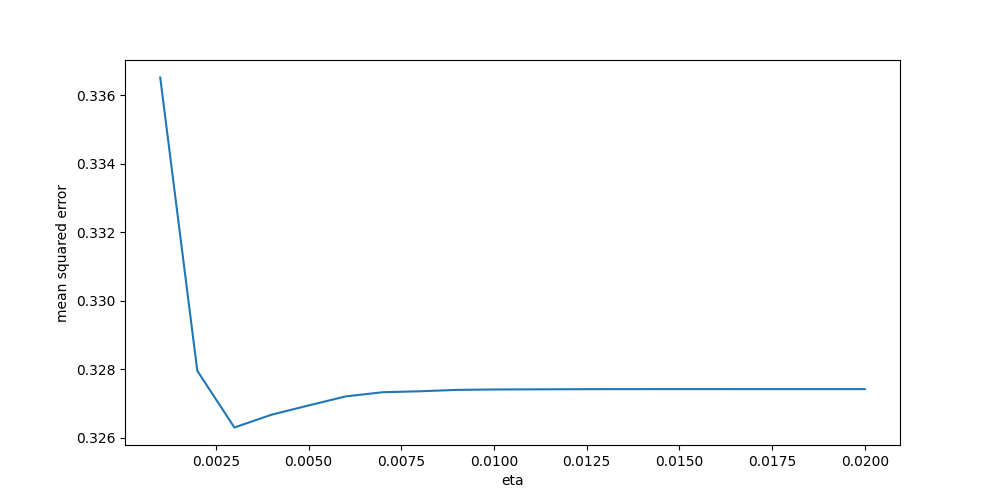

best eta: 0.003
best cross validation mean squared error: 0.3263039881939529
worst eta: 0.001
worst cross validation mean squared error: 0.3365243861248976
Elapsed time: 13.956815719604492
test mean squared error: 0.19503192937023617
test mean squared error at worst eta: 0.20238114320106462


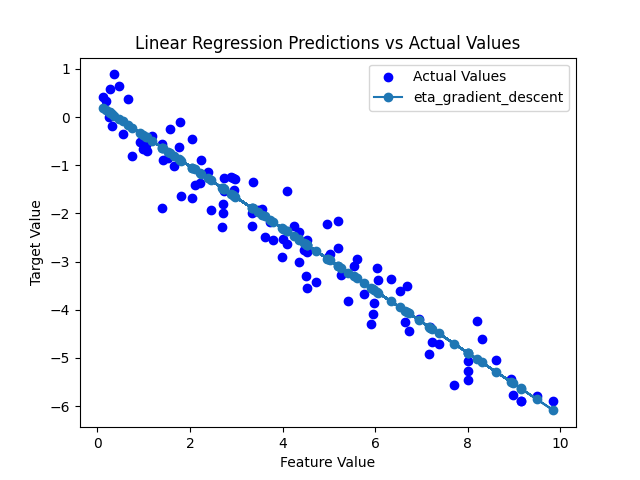

RUNNING quad, eta_gradient_descent


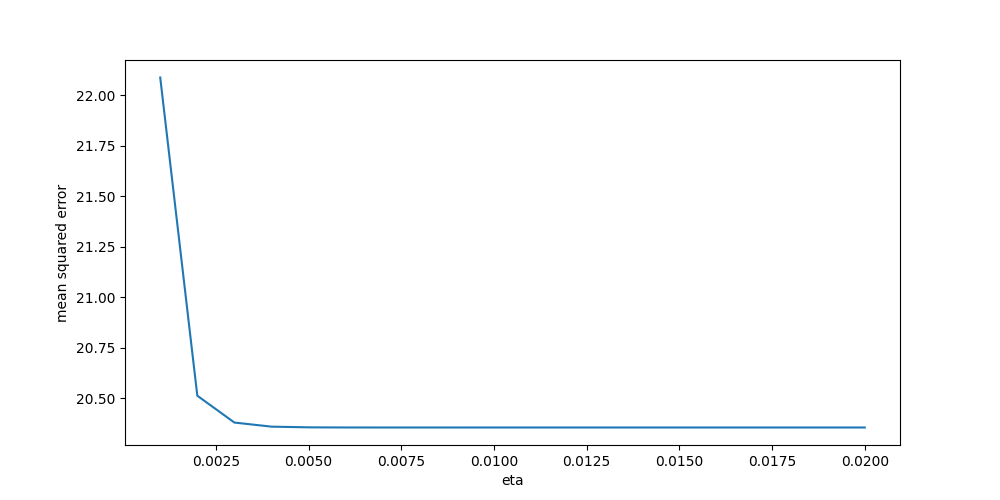

best eta: 0.019
best cross validation mean squared error: 20.356271254285947
worst eta: 0.001
worst cross validation mean squared error: 22.08779917033361
Elapsed time: 24.28919768333435
test mean squared error: 31.31723630546435
test mean squared error at worst eta: 33.73641215648608


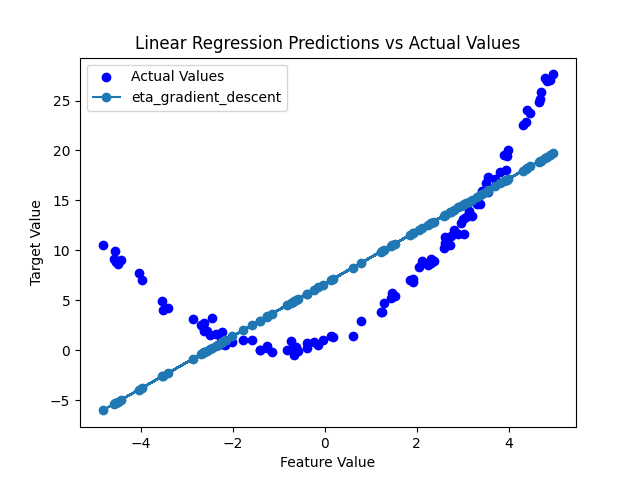

RUNNING house, eta_gradient_descent


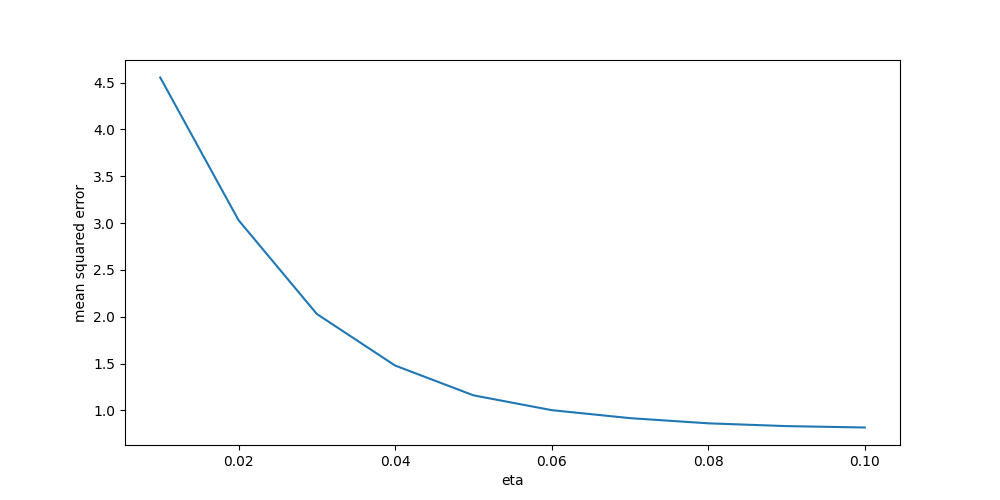

best eta: 0.1
best cross validation mean squared error: 0.817615276021512
worst eta: 0.01
worst cross validation mean squared error: 4.55358546420428
Elapsed time: 39.14227271080017
test mean squared error: 3.552664095123536
test mean squared error at worst eta: 0.9113648860256965
plot_linear_predictor only accepts 1D or 2D data + bias
RUNNING 49, eta_gradient_descent


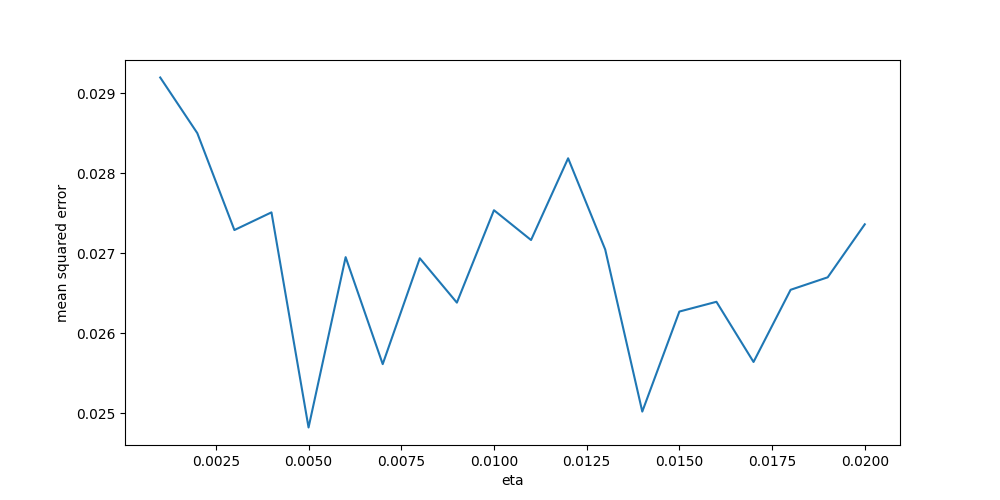

best eta: 0.005
best cross validation mean squared error: 0.024823036635828816
worst eta: 0.001
worst cross validation mean squared error: 0.02919620427581133
Elapsed time: 369.9124946594238
test mean squared error: 0.02917781369881796
test mean squared error at worst eta: 0.032676969375903996
plot_linear_predictor only accepts 1D or 2D data + bias
Test accuracy for digits is 0.99


In [8]:
small = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
tiny = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02]

datasets = {
    "synth": {
        "load": load_synthetic_excel_data,
        "etas": tiny,
        "lambda": 0.0
    },
    "quad": {
        "load": load_synthetic_quadratic_excel_data,
        "etas": tiny,
        "lambda": 0.0
    },
    "house": {
        "load": load_sklearn_california_housing,
        "etas": small,
        "lambda": 0.0
    },
    "49": {
        "load": load_sklearn_49_digits_data,
        "etas": tiny,
        "lambda": 0.0
    },
}
algorithms = {
    "eta_gradient_descent": {
        "train": train_linear_regression_gradient_descent,
        "validation": cross_validation_eta_gradient_descent,
        "regularization": 1.0}
}

k_folds = 10
num_iterations = 1000

for dataset_name, dataset_info in datasets.items():
    for alg_name, alg in algorithms.items():
        load_dataset = dataset_info["load"]
        lambda_hyperparam = dataset_info["lambda"]
        eta_hyperparams = dataset_info["etas"]
        run_train = alg["train"]
        run_validation = alg["validation"]
        regularization = alg["regularization"]
        
        print(f"RUNNING {dataset_name}, {alg_name}")
        train_inputs, train_targets, test_inputs, test_targets = load_dataset(plot=False)

        # add bias term (1) to each data point
        train_inputs = np.concatenate((np.ones((train_inputs.shape[0],1)),train_inputs),1)
        test_inputs = np.concatenate((np.ones((test_inputs.shape[0],1)),test_inputs),1)
        start_time = time()
        mean_squared_errors = (
            run_validation(
                inputs=train_inputs,
                targets=train_targets,
                k_folds=k_folds,
                eta_hyperparams=eta_hyperparams,
                lambda_hyperparam=lambda_hyperparam,
                lasso_ridge_ratio=regularization,
                num_iterations=num_iterations
            )
        )

        best_eta, best_mean_squared_error = min(mean_squared_errors.items(), key=lambda x: x[1])
        worst_eta, worst_mean_squared_error = max(mean_squared_errors.items(), key=lambda x: x[1])
        mean_squared_errors = list(mean_squared_errors.values())

        end_time = time()
        # plot results
        plot_eta_vs_mean_squared_errors(mean_squared_errors,eta_hyperparams)
        print('best eta: ' + str (best_eta))
        print('best cross validation mean squared error: ' + str(best_mean_squared_error))
        print('worst eta: ' + str(worst_eta))
        print('worst cross validation mean squared error: ' + str(worst_mean_squared_error))
        print(f"Elapsed time: {end_time - start_time}")

        # train and evaluate with best eta
        weights = run_train(
            train_inputs,
            train_targets,
            eta_hyperparam=best_eta,
            lambda_hyperparam=lambda_hyperparam,
            lasso_ridge_ratio=regularization,
            num_iterations=num_iterations)
        mean_squared_error = eval_linear_regression(test_inputs, weights, test_targets)
        print('test mean squared error: ' + str(mean_squared_error))

        # same again at the worst eta from the search
        worst_weights = run_train(
            train_inputs,
            train_targets,
            eta_hyperparam=worst_eta,
            lambda_hyperparam=lambda_hyperparam,
            lasso_ridge_ratio=regularization,
            num_iterations=num_iterations)
        worst_test_mean_squared_error = eval_linear_regression(test_inputs, worst_weights, test_targets)
        print('test mean squared error at worst eta: ' + str(worst_test_mean_squared_error))

        plot_linear_predictor(test_inputs, test_targets, {alg_name: weights})

        if load_dataset == load_sklearn_49_digits_data:
            accuracy = digits_accuracy(predict_linear_regression(test_inputs, weights), test_targets)
            print(f"Test accuracy for digits is {accuracy}")

Running synth, lambda_ridge_gradient_descent


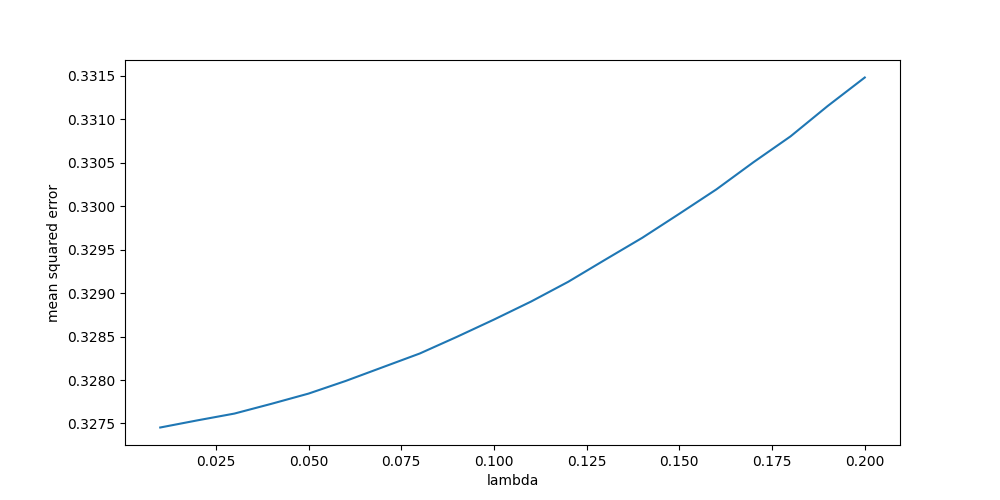

Results for synth, lambda_ridge_gradient_descent
best lambda: 0.01
best cross validation mean squared error: 0.32745362509056336
worst lambda: 0.2
worst cross validation mean squared error: 0.3314826085860435
Elapsed time: 10.957937955856323
test mean squared error: 0.19631844190760556
test mean squared error at worst lambda: 0.19871295550041515


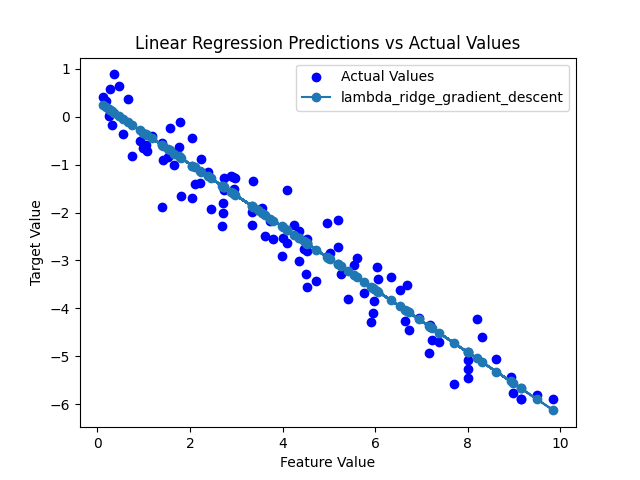

End results for synth, lambda_ridge_gradient_descent
Running synth, lambda_ridge_normal_equation


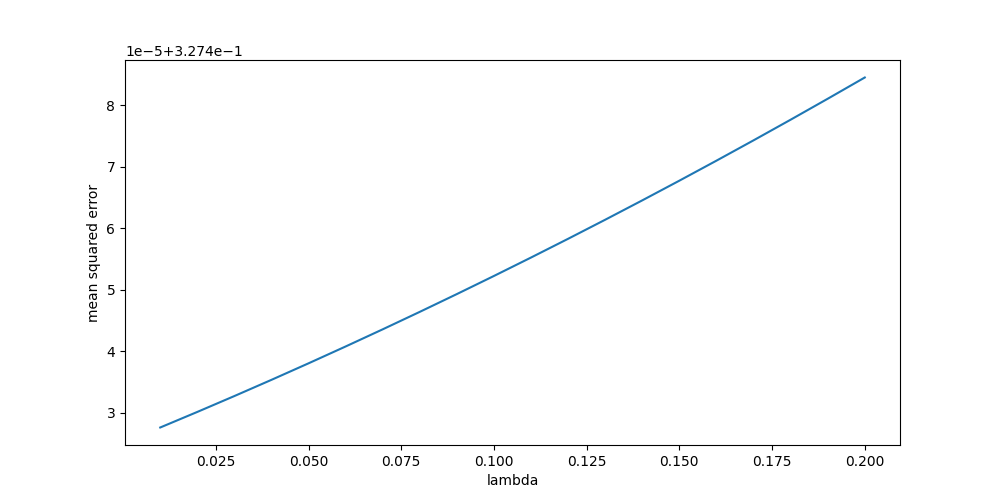

Results for synth, lambda_ridge_normal_equation
best lambda: 0.01
best cross validation mean squared error: 0.3274276189153965
worst lambda: 0.2
worst cross validation mean squared error: 0.3274845309357822
Elapsed time: 0.0249786376953125
test mean squared error: 0.19635477917405592
test mean squared error at worst lambda: 0.19635745039531036


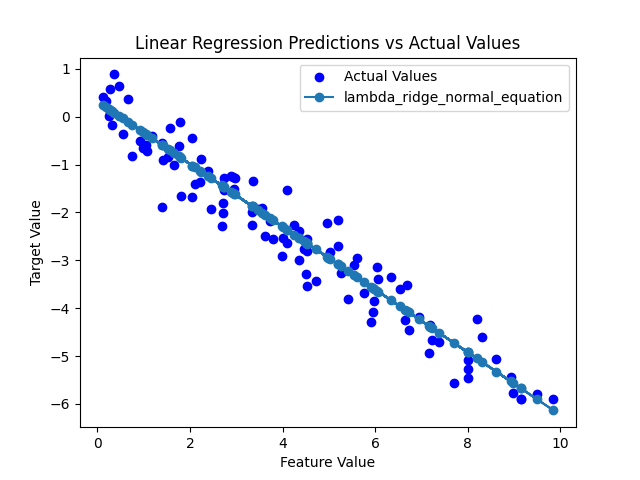

End results for synth, lambda_ridge_normal_equation
Running quad, lambda_ridge_gradient_descent


C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:42: RuntimeWarning: overflow encountered in scalar multiply
  regularization_gradient = lambda_hyperparam * (lasso_ridge_ratio * l1_gradient + (1 - lasso_ridge_ratio) * l2_gradient)
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:37: RuntimeWarning: invalid value encountered in scalar add
  mse_gradient[i] += train_inputs[j][i] * errors[j]
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  weights[i] -= eta_hyperparam * mse_gradient[i]
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:37: RuntimeWarning: overflow encountered in scalar add
  mse_gradient[i] += train_inputs[j][i] * errors[j]
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:43: RuntimeWarning: overflow encountered in scalar add
  mse_gradient[i] += regularization_gradient


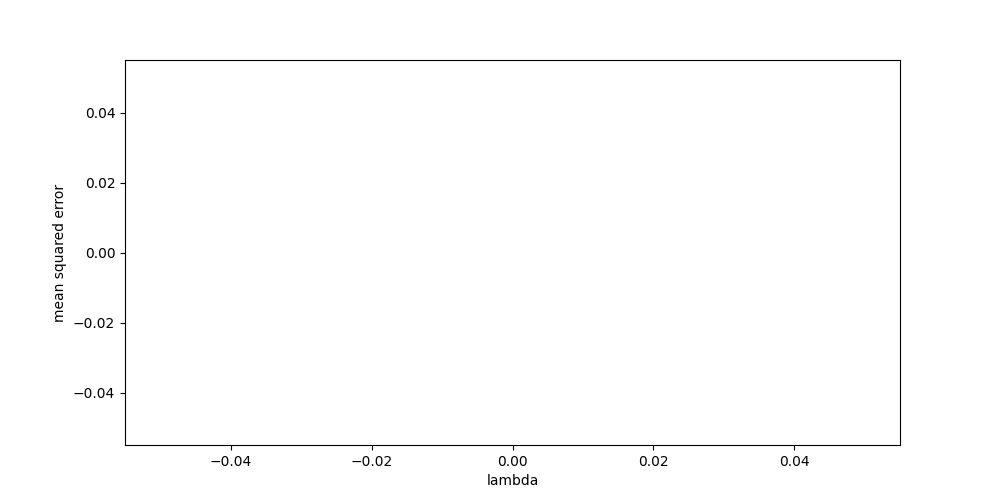

Results for quad, lambda_ridge_gradient_descent
best lambda: 100.0
best cross validation mean squared error: nan
worst lambda: 100.0
worst cross validation mean squared error: nan
Elapsed time: 10.51100468635559
test mean squared error: nan
test mean squared error at worst lambda: nan


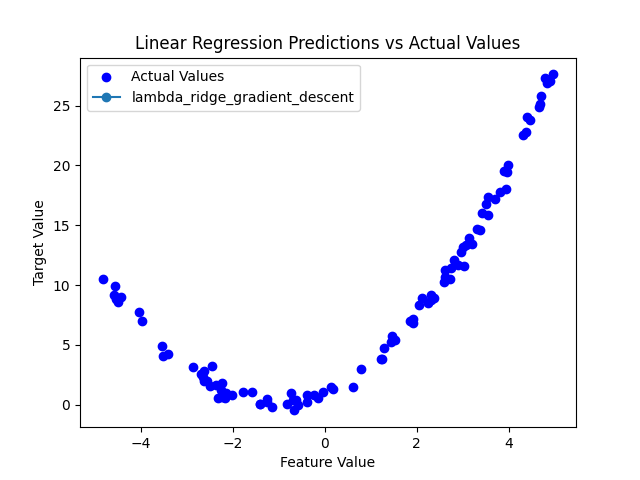

End results for quad, lambda_ridge_gradient_descent
Running quad, lambda_ridge_normal_equation


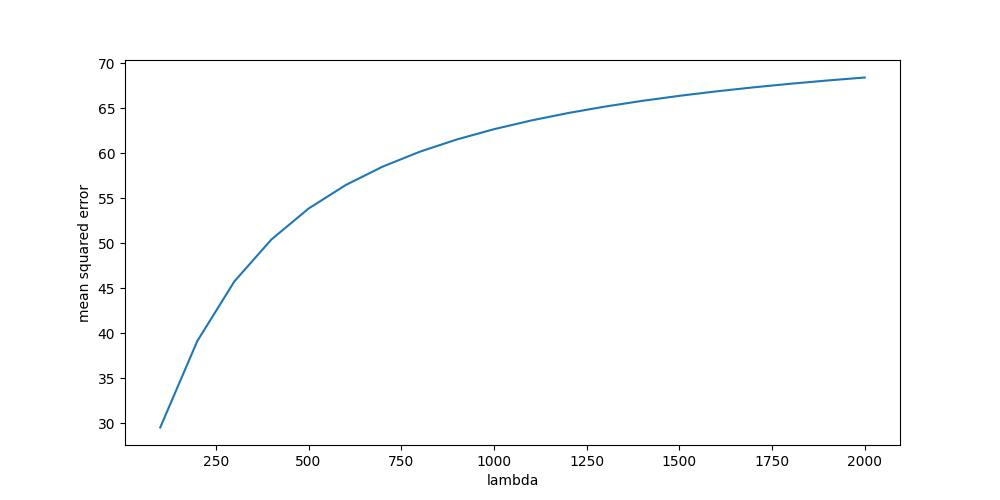

Results for quad, lambda_ridge_normal_equation
best lambda: 100.0
best cross validation mean squared error: 29.552673358797136
worst lambda: 2000.0
worst cross validation mean squared error: 68.43175008503351
Elapsed time: 0.01858067512512207
test mean squared error: 31.1118420325435
test mean squared error at worst lambda: 59.18169261378178


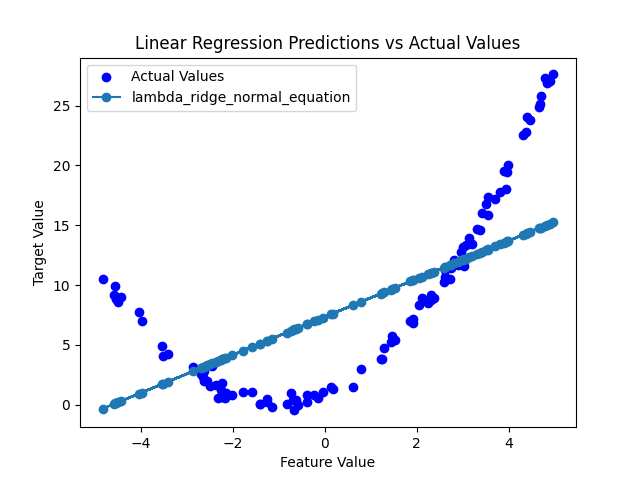

End results for quad, lambda_ridge_normal_equation
Running house, lambda_ridge_gradient_descent


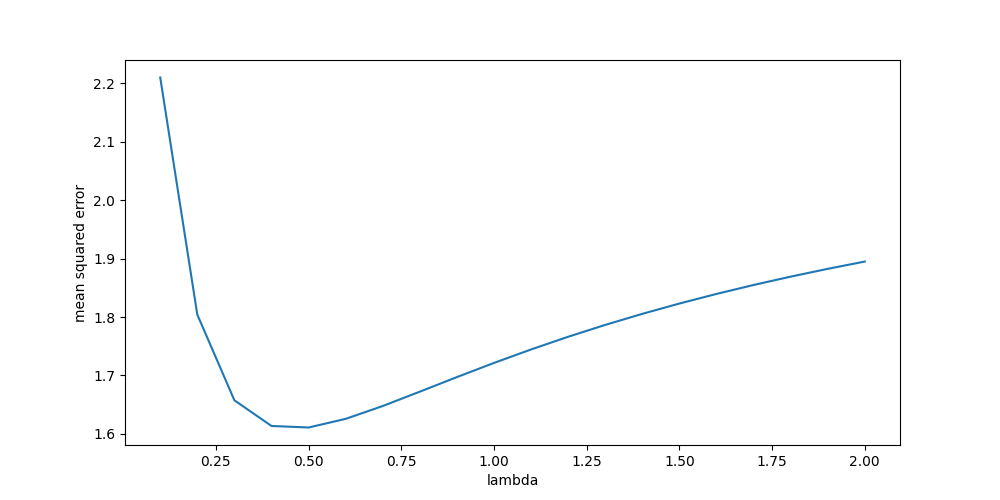

Results for house, lambda_ridge_gradient_descent
best lambda: 0.5
best cross validation mean squared error: 1.6109177024279955
worst lambda: 0.1
worst cross validation mean squared error: 2.210199313833796
Elapsed time: 44.84677267074585
test mean squared error: 0.4785276047032197
test mean squared error at worst lambda: 0.5512194081515627
plot_linear_predictor only accepts 1D or 2D data + bias
End results for house, lambda_ridge_gradient_descent
Running house, lambda_ridge_normal_equation


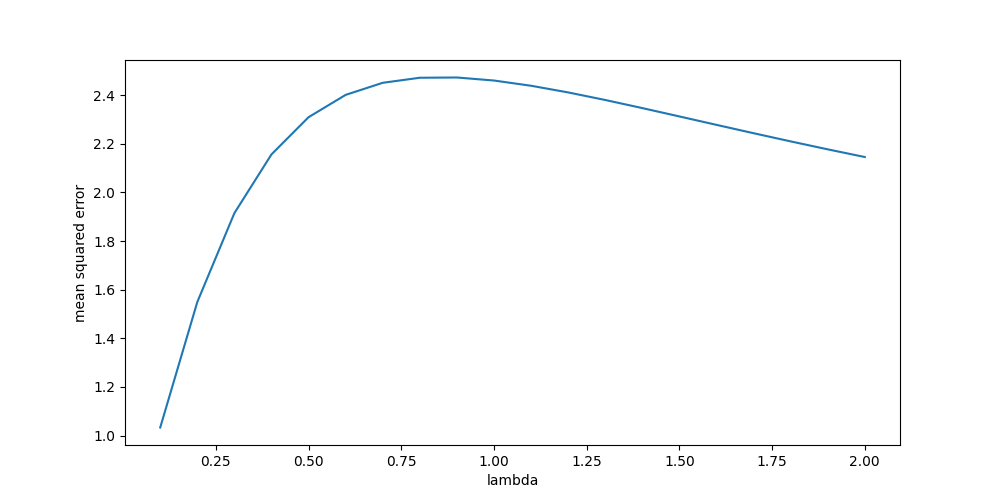

Results for house, lambda_ridge_normal_equation
best lambda: 0.1
best cross validation mean squared error: 1.0329863609401337
worst lambda: 0.9
worst cross validation mean squared error: 2.473033179135494
Elapsed time: 0.40169572830200195
test mean squared error: 2.3728277518161702
test mean squared error at worst lambda: 0.7729977137265749
plot_linear_predictor only accepts 1D or 2D data + bias
End results for house, lambda_ridge_normal_equation
Running 49, lambda_ridge_gradient_descent


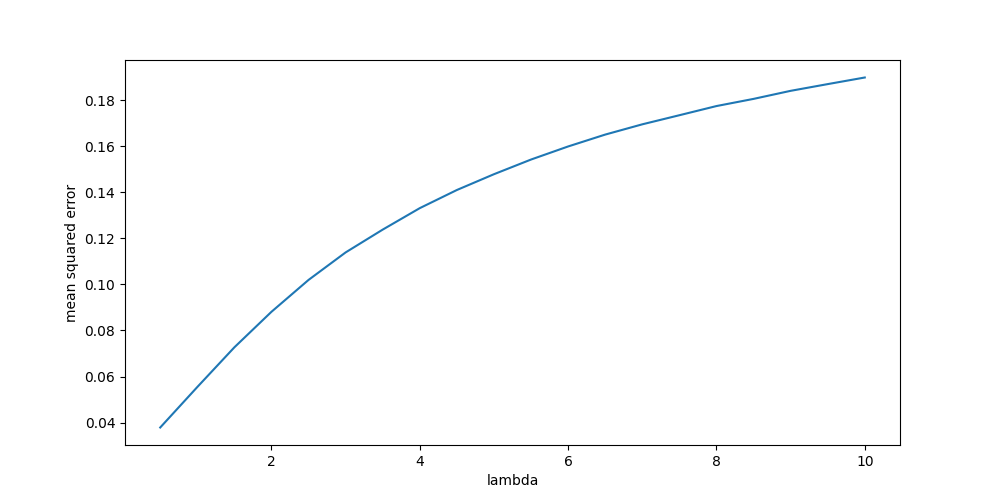

Results for 49, lambda_ridge_gradient_descent
best lambda: 0.5
best cross validation mean squared error: 0.03787115549658664
worst lambda: 10.0
worst cross validation mean squared error: 0.189808502411898
Elapsed time: 257.91907715797424
test mean squared error: 0.05000442789514656
test mean squared error at worst lambda: 0.20115776338952812
plot_linear_predictor only accepts 1D or 2D data + bias
Test accuracy for digits is 0.96
End results for 49, lambda_ridge_gradient_descent
Running 49, lambda_ridge_normal_equation


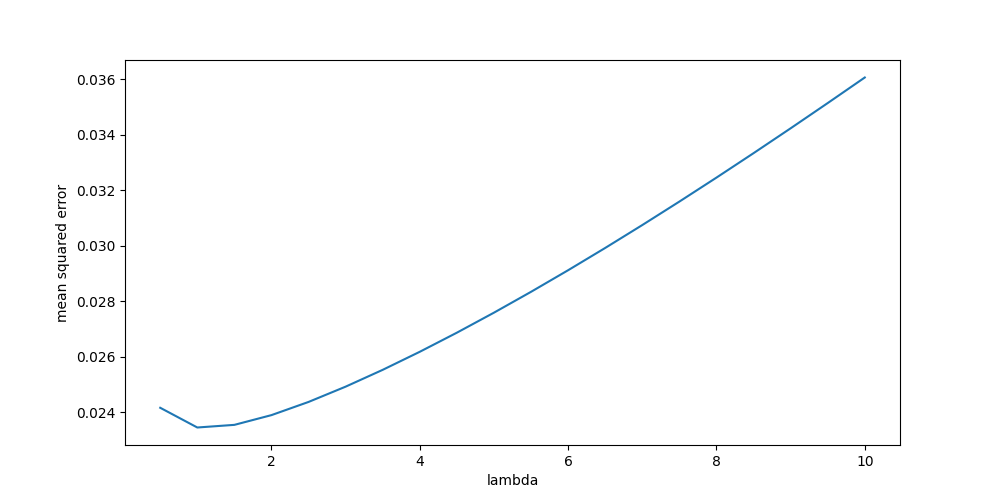

Results for 49, lambda_ridge_normal_equation
best lambda: 1.0
best cross validation mean squared error: 0.023442786573691914
worst lambda: 10.0
worst cross validation mean squared error: 0.03607011661140808
Elapsed time: 13.05112886428833
test mean squared error: 0.029889531659357774
test mean squared error at worst lambda: 0.04688045496796352
plot_linear_predictor only accepts 1D or 2D data + bias
Test accuracy for digits is 0.99
End results for 49, lambda_ridge_normal_equation


In [9]:
massive = [100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0]
half = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
normal = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
small = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]

datasets = {
    "synth": {
        "load": load_synthetic_excel_data,
        "eta": 0.009,
        "lambdas": small
    },
    "quad": {
        "load": load_synthetic_quadratic_excel_data,
        "eta": 0.02,
        "lambdas": massive
    },
    "house": {
        "load": load_sklearn_california_housing,
        "eta": 0.07,
        "lambdas": normal
    },
    "49": {
        "load": load_sklearn_49_digits_data,
        "eta": 0.002,
        "lambdas": half
    },
}
# lasso_ridge_ratio: 1.0 is all L1, 0.0 is all L2
algorithms = {
    "lambda_ridge_gradient_descent": {
        "train": train_linear_regression_gradient_descent,
        "validation": cross_validation_lambda_gradient_descent,
        "regularization": 0.0
        },
    "lambda_ridge_normal_equation": {
        "train": train_linear_regression_normal_equation,
        "validation": cross_validation_lambda_normal_equation,
        "regularization": 0.0
        },
}

k_folds = 10
num_iterations = 1000


for dataset_name, dataset_info in datasets.items():
    for alg_name, alg in algorithms.items():
        load_dataset = dataset_info["load"]
        lambda_hyperparams = dataset_info["lambdas"]
        eta_hyperparam = dataset_info["eta"]
        run_train = alg["train"]
        run_validation = alg["validation"]
        regularization = alg["regularization"]
        
        print(f"Running {dataset_name}, {alg_name}")
        train_inputs, train_targets, test_inputs, test_targets = load_dataset(plot=False)

        # add bias term (1) to each data point
        train_inputs = np.concatenate((np.ones((train_inputs.shape[0],1)),train_inputs),1)
        test_inputs = np.concatenate((np.ones((test_inputs.shape[0],1)),test_inputs),1)
        start_time = time()
        # normal equation is closed form, so no eta/ratio/iterations
        if run_validation is cross_validation_lambda_normal_equation:
            mean_squared_errors = (
                run_validation(
                    inputs=train_inputs,
                    targets=train_targets,
                    k_folds=k_folds,
                    lambda_hyperparams=lambda_hyperparams
                )
            )
        else:
            mean_squared_errors = (
                run_validation(
                    inputs=train_inputs,
                    targets=train_targets,
                    k_folds=k_folds,
                    eta_hyperparam=eta_hyperparam,
                    lambda_hyperparams=lambda_hyperparams,
                    lasso_ridge_ratio=regularization,
                    num_iterations=num_iterations
                )
            )

        best_lambda, best_mean_squared_error = min(mean_squared_errors.items(), key=lambda x: x[1])
        worst_lambda, worst_mean_squared_error = max(mean_squared_errors.items(), key=lambda x: x[1])
        mean_squared_errors = list(mean_squared_errors.values())

        end_time = time()
        # plot results
        plot_lambda_vs_mean_squared_errors(mean_squared_errors, lambda_hyperparams)
        print(f"Results for {dataset_name}, {alg_name}")
        print('best lambda: ' + str (best_lambda))
        print('best cross validation mean squared error: ' + str(best_mean_squared_error))
        print('worst lambda: ' + str(worst_lambda))
        print('worst cross validation mean squared error: ' + str(worst_mean_squared_error))
        print(f"Elapsed time: {end_time - start_time}")

        # train and evaluate with best lambda
        if run_train is train_linear_regression_normal_equation:
            weights = run_train(train_inputs, train_targets, best_lambda)
        else:
            weights = run_train(
                train_inputs,
                train_targets,
                eta_hyperparam=eta_hyperparam,
                lambda_hyperparam=best_lambda,
                lasso_ridge_ratio=regularization,
                num_iterations=num_iterations)
        mean_squared_error = eval_linear_regression(test_inputs, weights, test_targets)
        print('test mean squared error: ' + str(mean_squared_error))

        # same again at the worst lambda from the search
        if run_train is train_linear_regression_normal_equation:
            worst_weights = run_train(train_inputs, train_targets, worst_lambda)
        else:
            worst_weights = run_train(
                train_inputs,
                train_targets,
                eta_hyperparam=eta_hyperparam,
                lambda_hyperparam=worst_lambda,
                lasso_ridge_ratio=regularization,
                num_iterations=num_iterations)
        worst_test_mean_squared_error = eval_linear_regression(test_inputs, worst_weights, test_targets)
        print('test mean squared error at worst lambda: ' + str(worst_test_mean_squared_error))

        plot_linear_predictor(test_inputs, test_targets, {alg_name: weights})

        if load_dataset == load_sklearn_49_digits_data:
            accuracy = digits_accuracy(predict_linear_regression(test_inputs, weights), test_targets)
            print(f"Test accuracy for digits is {accuracy}")
        
        print(f"End results for {dataset_name}, {alg_name}")

Running synth, lambda_ridge_gradient_descent
test mean squared error: 0.19631913758169312
End results for synth, lambda_ridge_gradient_descent
Running synth, lambda_LASSO_gradient_descent
test mean squared error: 0.1963165882113148
End results for synth, lambda_LASSO_gradient_descent
Running synth, lambda_ridge_normal_equation
test mean squared error: 0.19635477917405592
End results for synth, lambda_ridge_normal_equation
Running synth, no_lambda_gradient_descent
test mean squared error: 0.19631386934652728
End results for synth, no_lambda_gradient_descent


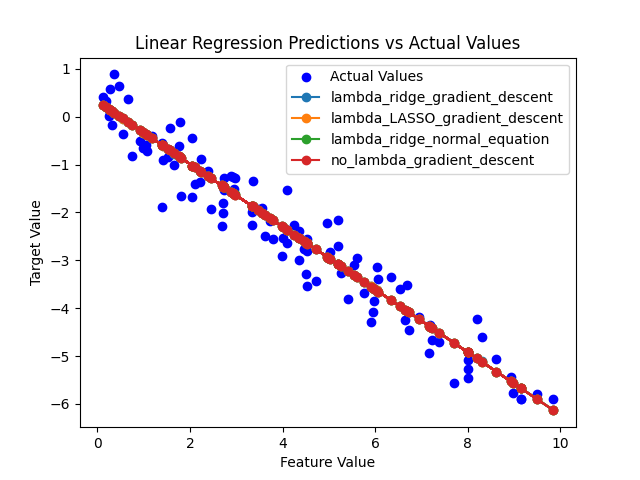

Running quad, lambda_ridge_gradient_descent
test mean squared error: nan
End results for quad, lambda_ridge_gradient_descent
Running quad, lambda_LASSO_gradient_descent
test mean squared error: 113.2422323481457
End results for quad, lambda_LASSO_gradient_descent
Running quad, lambda_ridge_normal_equation
test mean squared error: 41.0631623727295
End results for quad, lambda_ridge_normal_equation
Running quad, no_lambda_gradient_descent
test mean squared error: 31.31723630546435
End results for quad, no_lambda_gradient_descent


C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:42: RuntimeWarning: overflow encountered in scalar multiply
  regularization_gradient = lambda_hyperparam * (lasso_ridge_ratio * l1_gradient + (1 - lasso_ridge_ratio) * l2_gradient)
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:37: RuntimeWarning: invalid value encountered in scalar add
  mse_gradient[i] += train_inputs[j][i] * errors[j]
C:\Users\An Nguyen\AppData\Local\Temp\ipykernel_51504\3317726887.py:45: RuntimeWarning: invalid value encountered in scalar subtract
  weights[i] -= eta_hyperparam * mse_gradient[i]


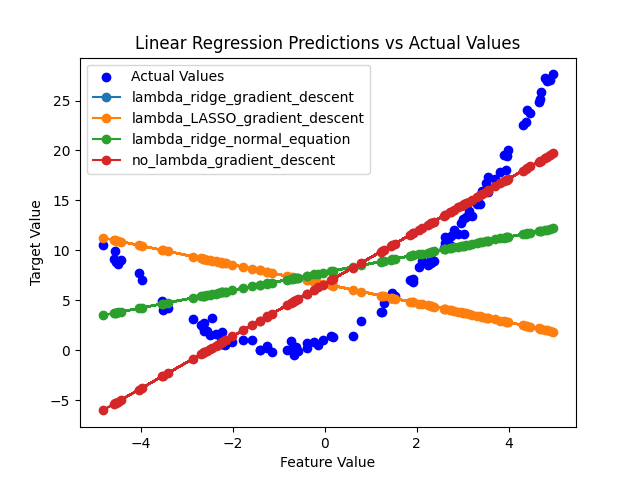

Running house, lambda_ridge_gradient_descent
test mean squared error: 0.6976767144862691
End results for house, lambda_ridge_gradient_descent
Running house, lambda_LASSO_gradient_descent
test mean squared error: 2.864003761387465
End results for house, lambda_LASSO_gradient_descent
Running house, lambda_ridge_normal_equation
test mean squared error: 0.5512194097948508
End results for house, lambda_ridge_normal_equation
Running house, no_lambda_gradient_descent
test mean squared error: 3.3551978572020804
End results for house, no_lambda_gradient_descent
plot_linear_predictor only accepts 1D or 2D data + bias
Running 49, lambda_ridge_gradient_descent
test mean squared error: 0.07161794347425
Test accuracy for digits is 0.96
End results for 49, lambda_ridge_gradient_descent
Running 49, lambda_LASSO_gradient_descent
test mean squared error: 0.2550359058659939
Test accuracy for digits is 0.51
End results for 49, lambda_LASSO_gradient_descent
Running 49, lambda_ridge_normal_equation
test mea

In [10]:
datasets = {
    "synth": {
        "load": load_synthetic_excel_data,
        "eta": 0.009,
        "lambda": 0.01
    },
    "quad": {
        "load": load_synthetic_quadratic_excel_data,
        "eta": 0.02,
        "lambda": 300.0
    },
    "house": {
        "load": load_sklearn_california_housing,
        "eta": 0.07,
        "lambda": 2.0
    },
    "49": {
        "load": load_sklearn_49_digits_data,
        "eta": 0.002,
        "lambda": 1.0
    },
}
# lasso_ridge_ratio: 1.0 is all L1, 0.0 is all L2
algorithms = {
    "lambda_ridge_gradient_descent": {
        "train": train_linear_regression_gradient_descent,
        "regularization": 0.0,
        "use_regularization": True
        },
    "lambda_LASSO_gradient_descent": {
        "train": train_linear_regression_gradient_descent,
        "regularization": 1.0,
        "use_regularization": True
        },
    "lambda_ridge_normal_equation": {
        "train": train_linear_regression_normal_equation,
        "regularization": 0.0,
        "use_regularization": True
        },
    "no_lambda_gradient_descent": {
        "train": train_linear_regression_gradient_descent,
        "regularization": 1.0,
        "use_regularization": False
        },
}

k_folds = 10
num_iterations = 1000

for dataset_name, dataset_info in datasets.items():
    models = {}
    for alg_name, alg in algorithms.items():
        load_dataset = dataset_info["load"]
        lambda_hyperparam = dataset_info["lambda"]
        eta_hyperparam = dataset_info["eta"]
        run_train = alg["train"]
        regularization = alg["regularization"]
        use_regularization = alg["use_regularization"]
        lambda_hyperparam = lambda_hyperparam if use_regularization else 0
        
        print(f"Running {dataset_name}, {alg_name}")
        train_inputs, train_targets, test_inputs, test_targets = load_dataset(plot=False)

        # add bias term (1) to each data point
        train_inputs = np.concatenate((np.ones((train_inputs.shape[0],1)),train_inputs),1)
        test_inputs = np.concatenate((np.ones((test_inputs.shape[0],1)),test_inputs),1)

        # train and evaluate model
        # normal equation is closed form, so no eta/ratio/iterations
        if run_train is train_linear_regression_normal_equation:
            weights = run_train(train_inputs, train_targets, lambda_hyperparam)
        else:
            weights = run_train(
                train_inputs,
                train_targets,
                eta_hyperparam=eta_hyperparam,
                lambda_hyperparam=lambda_hyperparam,
                lasso_ridge_ratio=regularization,
                num_iterations=num_iterations)
        models[alg_name] = weights
        mean_squared_error = eval_linear_regression(test_inputs, weights, test_targets)
        print('test mean squared error: ' + str(mean_squared_error))

        if load_dataset == load_sklearn_49_digits_data:
            accuracy = digits_accuracy(predict_linear_regression(test_inputs, weights), test_targets)
            print(f"Test accuracy for digits is {accuracy}")
        
        print(f"End results for {dataset_name}, {alg_name}")
    
    plot_linear_predictor(test_inputs, test_targets, models)